<a href="https://colab.research.google.com/github/prksh830/Pancreatic-Cancer/blob/main/Pancreatic_Cancer_Task07_Pancreas-preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q nibabel
!pip install -q SimpleITK
!pip install -q monai
!pip install -q torchio
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Pancreatic Cancer Dataset/Task07_Pancreas"

images_path = f"{dataset_path}/imagesTr"
labels_path = f"{dataset_path}/labelsTr"

In [ ]:
images_path = f"{dataset_path}/imagesTr"
labels_path = f"{dataset_path}/labelsTr"

In [ ]:
import os

print(os.listdir(dataset_path))

['._dataset.json', '._labelsTr', '._imagesTs', 'dataset.json', '._imagesTr', 'labelsTr', 'imagesTs', 'imagesTr']


In [ ]:
print("Images:", len(os.listdir(images_path)))
print("Labels:", len(os.listdir(labels_path)))

Images: 284
Labels: 282


In [ ]:
print("ImagesTr:", len(os.listdir(images_path)))
print("LabelsTr:", len(os.listdir(labels_path)))

test_path = f"{dataset_path}/imagesTs"

print("ImagesTs:", len(os.listdir(test_path)))

ImagesTr: 284
LabelsTr: 282
ImagesTs: 146


In [ ]:
print(sorted(os.listdir(images_path))[:5])
print(sorted(os.listdir(images_path))[-5:])

['._pancreas_001.nii.gz', '._pancreas_004.nii.gz', 'pancreas_001.nii', 'pancreas_004.nii', 'pancreas_005.nii']
['pancreas_415.nii', 'pancreas_416.nii', 'pancreas_418.nii', 'pancreas_419.nii', 'pancreas_421.nii']


In [ ]:
print(sorted(os.listdir(labels_path))[:5])
print(sorted(os.listdir(labels_path))[-5:])

['._pancreas_004.nii.gz', 'pancreas_001.nii', 'pancreas_004.nii', 'pancreas_005.nii', 'pancreas_006.nii']
['pancreas_415.nii', 'pancreas_416.nii', 'pancreas_418.nii', 'pancreas_419.nii', 'pancreas_421.nii']


In [ ]:
import os

image_files = sorted([
    f for f in os.listdir(images_path)
    if f.endswith('.nii')
    and not f.startswith('._')
])

label_files = sorted([
    f for f in os.listdir(labels_path)
    if f.endswith('.nii')
    and not f.startswith('._')
])

print("Actual Images:", len(image_files))
print("Actual Labels:", len(label_files))

Actual Images: 282
Actual Labels: 281


In [ ]:
image_ids = set([f.replace('.nii', '') for f in image_files])
label_ids = set([f.replace('.nii', '') for f in label_files])

print("Images without labels:")
print(sorted(image_ids - label_ids))

print("\nLabels without images:")
print(sorted(label_ids - image_ids))

Images without labels:
['pancreas_056 (1)']

Labels without images:
[]


In [ ]:
[f for f in image_files if "056" in f]

['pancreas_056 (1).nii', 'pancreas_056.nii']

In [ ]:
image_files = sorted([
    f for f in os.listdir(images_path)
    if f.endswith('.nii')
    and not f.startswith('._')
    and '(1)' not in f
])

label_files = sorted([
    f for f in os.listdir(labels_path)
    if f.endswith('.nii')
    and not f.startswith('._')
])

print("Images:", len(image_files))
print("Labels:", len(label_files))

Images: 281
Labels: 281


In [ ]:
image_ids = set([f.replace('.nii','') for f in image_files])
label_ids = set([f.replace('.nii','') for f in label_files])

print("Missing Labels:", image_ids-label_ids)
print("Missing Images:", label_ids-image_ids)

Missing Labels: set()
Missing Images: set()


In [ ]:
import nibabel as nib
import os

sample_image = os.path.join(images_path, image_files[0])

img = nib.load(sample_image)

volume = img.get_fdata()

print("Filename:", image_files[0])
print("Shape:", volume.shape)
print("Voxel Spacing:", img.header.get_zooms())
print("Data Type:", volume.dtype)

print("Minimum HU:", volume.min())
print("Maximum HU:", volume.max())

Filename: pancreas_001.nii
Shape: (512, 512, 110)
Voxel Spacing: (np.float32(0.644531), np.float32(0.644531), np.float32(2.5))
Data Type: float64
Minimum HU: -1024.0
Maximum HU: 3071.0


In [ ]:
sample_label = os.path.join(labels_path, label_files[0])

mask = nib.load(sample_label)

mask_data = mask.get_fdata()

print("Mask Shape:", mask_data.shape)

print("Unique Labels:")
print(sorted(list(set(mask_data.flatten()))))

Mask Shape: (512, 512, 110)
Unique Labels:
[np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [ ]:
import json

with open(f"{dataset_path}/dataset.json") as f:
    meta = json.load(f)

print(meta["labels"])

{'0': 'background', '1': 'pancreas', '2': 'cancer'}


In [ ]:
print("Image Shape:", volume.shape)
print("Mask Shape :", mask_data.shape)

print("Shapes Match:",
      volume.shape == mask_data.shape)

Image Shape: (512, 512, 110)
Mask Shape : (512, 512, 110)
Shapes Match: True


In [ ]:
import numpy as np

slices_with_annotation = []

for z in range(mask_data.shape[2]):
    if np.sum(mask_data[:,:,z]) > 0:
        slices_with_annotation.append(z)

print("First annotated slice:",
      slices_with_annotation[0])

print("Last annotated slice:",
      slices_with_annotation[-1])

print("Number of annotated slices:",
      len(slices_with_annotation))

First annotated slice: 33
Last annotated slice: 61
Number of annotated slices: 29


In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm import tqdm

audit_data = []

for file in tqdm(image_files):

    img_path = os.path.join(images_path, file)
    lbl_path = os.path.join(labels_path, file)

    img = nib.load(img_path)
    mask = nib.load(lbl_path)

    volume = img.get_fdata()
    mask_data = mask.get_fdata()

    spacing = img.header.get_zooms()

    pancreas_voxels = np.sum(mask_data == 1)
    cancer_voxels = np.sum(mask_data == 2)

    audit_data.append([
        file,
        volume.shape[0],
        volume.shape[1],
        volume.shape[2],
        spacing[0],
        spacing[1],
        spacing[2],
        volume.min(),
        volume.max(),
        pancreas_voxels,
        cancer_voxels
    ])

audit_df = pd.DataFrame(
    audit_data,
    columns=[
        "Case",
        "X",
        "Y",
        "Z",
        "Spacing_X",
        "Spacing_Y",
        "Spacing_Z",
        "HU_Min",
        "HU_Max",
        "Pancreas_Voxels",
        "Cancer_Voxels"
    ]
)

audit_df.head()

100%|██████████| 281/281 [13:03<00:00,  2.79s/it]


,Case,X,Y,Z,Spacing_X,Spacing_Y,Spacing_Z,HU_Min,HU_Max,Pancreas_Voxels,Cancer_Voxels
0,pancreas_001.nii,512,512,110,0.644531,0.644531,2.5,-1024.0,3071.0,39557,26153
1,pancreas_004.nii,512,512,107,0.742188,0.742188,2.5,-1024.0,2926.0,71622,28448
2,pancreas_005.nii,512,512,104,0.917969,0.917969,2.5,-1024.0,2098.0,71062,3609
3,pancreas_006.nii,512,512,101,0.767578,0.767578,2.5,-1024.0,3071.0,70046,9244
4,pancreas_010.nii,512,512,174,0.976562,0.976562,1.5,-1024.0,2350.0,116491,53193


In [28]:
audit_df.to_csv(
    "/content/drive/MyDrive/Pancreatic Cancer Dataset/dataset_audit.csv",
    index=False
)

print(audit_df.shape)

(281, 11)


In [29]:
audit_df.describe()

,X,Y,Z,Spacing_X,Spacing_Y,Spacing_Z,HU_Min,HU_Max,Pancreas_Voxels,Cancer_Voxels
count,281.0,281.0,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000
mean,512.0,512.0,95.085409,0.812373,0.812373,2.900178,-1036.469751,2088.249110,47250.711744,7102.601423
std,0.0,0.0,48.470976,0.094261,0.094261,0.980711,106.703093,733.054701,25758.463141,23524.243826
min,512.0,512.0,37.000000,0.605469,0.605469,0.700012,-2048.000000,1141.000000,7537.000000,303.000000
25%,512.0,512.0,83.000000,0.740234,0.740234,2.500000,-1024.000000,1422.000000,30973.000000,1601.000000
50%,512.0,512.0,93.000000,0.802734,0.802734,2.500000,-1024.000000,1790.000000,41188.000000,2893.000000
75%,512.0,512.0,103.000000,0.892578,0.892578,2.500000,-1024.000000,3071.000000,56919.000000,5418.000000
max,512.0,512.0,751.000000,0.976562,0.976562,7.500000,-1024.000000,4009.000000,233567.000000,324028.000000


In [30]:
print(
    "Cases with Cancer:",
    (audit_df["Cancer_Voxels"] > 0).sum()
)

print(
    "Cases without Cancer:",
    (audit_df["Cancer_Voxels"] == 0).sum()
)

Cases with Cancer: 281
Cases without Cancer: 0


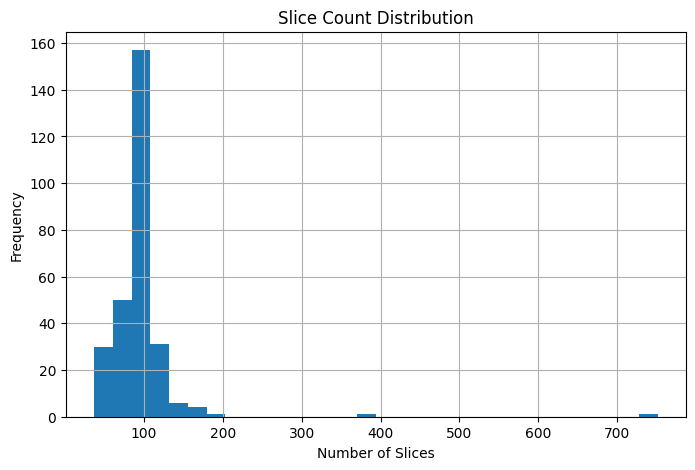

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

audit_df["Z"].hist(bins=30)

plt.xlabel("Number of Slices")
plt.ylabel("Frequency")
plt.title("Slice Count Distribution")

plt.show()

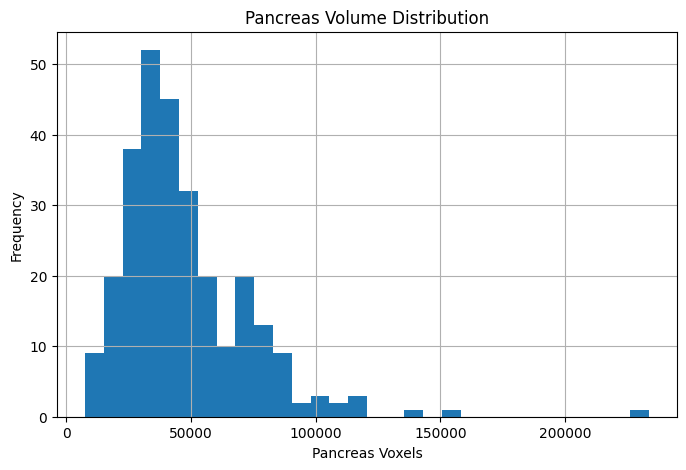

In [32]:
plt.figure(figsize=(8,5))

audit_df["Pancreas_Voxels"].hist(bins=30)

plt.xlabel("Pancreas Voxels")
plt.ylabel("Frequency")
plt.title("Pancreas Volume Distribution")

plt.show()

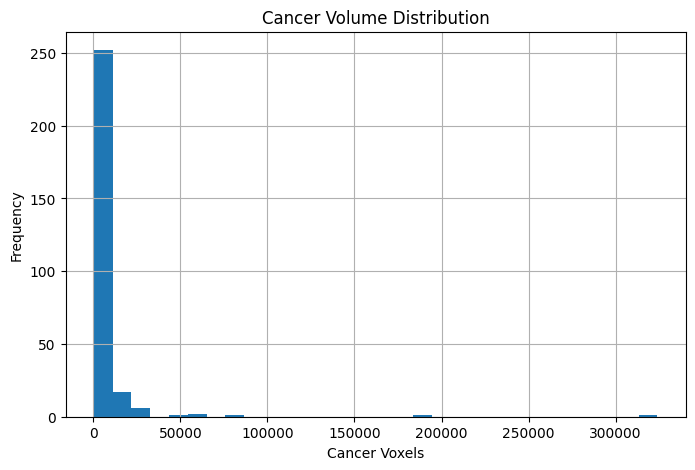

In [33]:
plt.figure(figsize=(8,5))

audit_df["Cancer_Voxels"].hist(bins=30)

plt.xlabel("Cancer Voxels")
plt.ylabel("Frequency")
plt.title("Cancer Volume Distribution")

plt.show()

In [34]:
audit_df["Cancer_Ratio"] = (
    audit_df["Cancer_Voxels"] /
    audit_df["Pancreas_Voxels"]
)

print(audit_df["Cancer_Ratio"].describe())

count    281.000000
mean       0.155953
std        0.399077
min        0.006024
25%        0.038752
50%        0.075724
75%        0.131265
max        5.416660
Name: Cancer_Ratio, dtype: float64


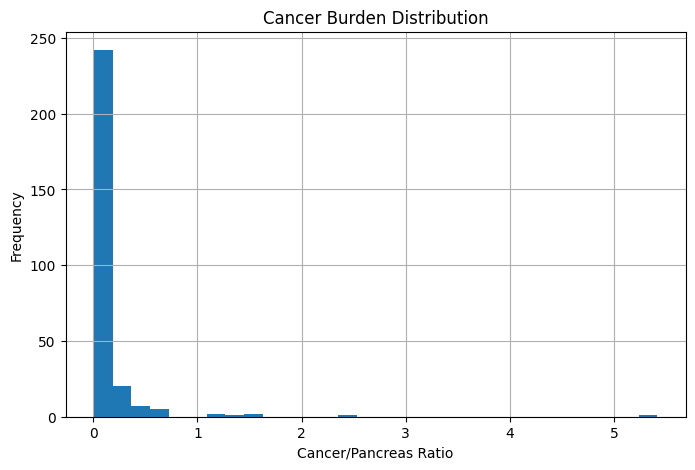

In [35]:
plt.figure(figsize=(8,5))

audit_df["Cancer_Ratio"].hist(bins=30)

plt.xlabel("Cancer/Pancreas Ratio")
plt.ylabel("Frequency")
plt.title("Cancer Burden Distribution")

plt.show()

In [36]:
audit_df.sort_values(
    "Cancer_Ratio",
    ascending=False
)[
    ["Case",
     "Pancreas_Voxels",
     "Cancer_Voxels",
     "Cancer_Ratio"]
].head(10)

,Case,Pancreas_Voxels,Cancer_Voxels,Cancer_Ratio
276,pancreas_415.nii,35007,189621,5.416660
243,pancreas_370.nii,26506,64032,2.415755
258,pancreas_391.nii,38541,61414,1.593472
275,pancreas_414.nii,50929,76733,1.506666
270,pancreas_409.nii,233567,324028,1.387302
255,pancreas_387.nii,18371,22847,1.243645
248,pancreas_377.nii,10549,12934,1.226088
253,pancreas_385.nii,18438,12754,0.691724
0,pancreas_001.nii,39557,26153,0.661147
108,pancreas_182.nii,31464,20299,0.645150


In [37]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

case = "pancreas_415.nii"

img = nib.load(
    os.path.join(images_path, case)
)

mask = nib.load(
    os.path.join(labels_path, case)
)

volume = img.get_fdata()
mask_data = mask.get_fdata()

print("Shape:", volume.shape)

print("Pancreas Voxels:",
      np.sum(mask_data==1))

print("Cancer Voxels:",
      np.sum(mask_data==2))

Shape: (512, 512, 61)
Pancreas Voxels: 35007
Cancer Voxels: 189621


In [38]:
cancer_slices = []

for z in range(mask_data.shape[2]):

    if np.sum(mask_data[:,:,z] == 2) > 0:
        cancer_slices.append(z)

print("First Cancer Slice:",
      cancer_slices[0])

print("Last Cancer Slice:",
      cancer_slices[-1])

First Cancer Slice: 22
Last Cancer Slice: 48


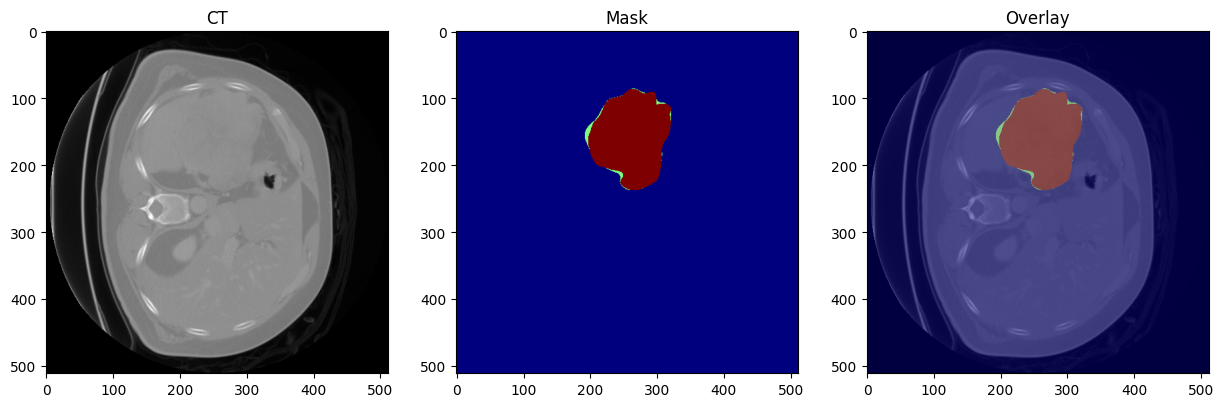

In [39]:
slice_idx = cancer_slices[
    len(cancer_slices)//2
]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(volume[:,:,slice_idx],
           cmap='gray')
plt.title("CT")

plt.subplot(1,3,2)
plt.imshow(mask_data[:,:,slice_idx],
           cmap='jet')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(volume[:,:,slice_idx],
           cmap='gray')

plt.imshow(mask_data[:,:,slice_idx],
           alpha=0.5,
           cmap='jet')

plt.title("Overlay")

plt.show()

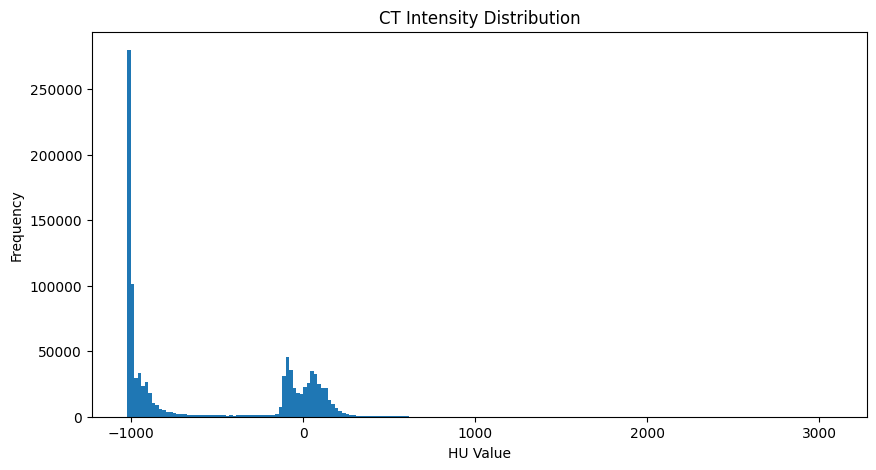

Min: -1024.0
Max: 3071.0
1st percentile: -1024.0
99th percentile: 274.0


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os

sample_cases = image_files[:10]

all_hu = []

for file in sample_cases:

    img = nib.load(
        os.path.join(images_path,file)
    )

    vol = img.get_fdata()

    sample = np.random.choice(
        vol.flatten(),
        size=min(100000,
                 vol.size),
        replace=False
    )

    all_hu.extend(sample)

all_hu = np.array(all_hu)

plt.figure(figsize=(10,5))

plt.hist(
    all_hu,
    bins=200
)

plt.xlabel("HU Value")
plt.ylabel("Frequency")
plt.title("CT Intensity Distribution")

plt.show()

print("Min:", all_hu.min())
print("Max:", all_hu.max())

print("1st percentile:",
      np.percentile(all_hu,1))

print("99th percentile:",
      np.percentile(all_hu,99))

In [43]:
audit_df[
    ["Spacing_X",
     "Spacing_Y",
     "Spacing_Z"]
].describe()

,Spacing_X,Spacing_Y,Spacing_Z
count,281.000000,281.000000,281.000000
mean,0.812373,0.812373,2.900178
std,0.094261,0.094261,0.980711
min,0.605469,0.605469,0.700012
25%,0.740234,0.740234,2.500000
50%,0.802734,0.802734,2.500000
75%,0.892578,0.892578,2.500000
max,0.976562,0.976562,7.500000


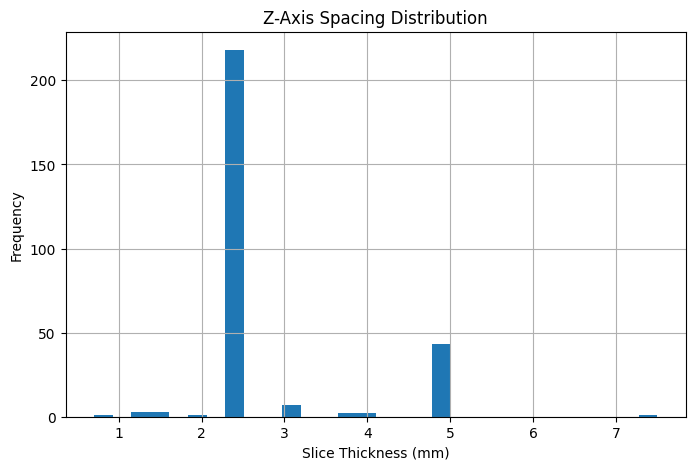

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

audit_df["Spacing_Z"].hist(
    bins=30
)

plt.xlabel("Slice Thickness (mm)")
plt.ylabel("Frequency")
plt.title("Z-Axis Spacing Distribution")

plt.show()

In [44]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.ndimage import zoom

pilot_results = []

target_spacing = (1.0, 1.0, 2.0)

for file in image_files[:10]:

    img = nib.load(os.path.join(images_path,file))

    volume = img.get_fdata()

    spacing = img.header.get_zooms()

    original_shape = volume.shape

    zoom_factors = [
        spacing[0]/target_spacing[0],
        spacing[1]/target_spacing[1],
        spacing[2]/target_spacing[2]
    ]

    new_shape = (
        np.array(original_shape) *
        np.array(zoom_factors)
    ).astype(int)

    pilot_results.append([
        file,
        original_shape,
        spacing,
        tuple(new_shape)
    ])

pilot_df = pd.DataFrame(
    pilot_results,
    columns=[
        "Case",
        "Original Shape",
        "Spacing",
        "Resampled Shape"
    ]
)

pilot_df

,Case,Original Shape,Spacing,Resampled Shape
0,pancreas_001.nii,"(512, 512, 110)","(0.644531, 0.644531, 2.5)","(329, 329, 137)"
1,pancreas_004.nii,"(512, 512, 107)","(0.742188, 0.742188, 2.5)","(380, 380, 133)"
2,pancreas_005.nii,"(512, 512, 104)","(0.917969, 0.917969, 2.5)","(470, 470, 130)"
3,pancreas_006.nii,"(512, 512, 101)","(0.767578, 0.767578, 2.5)","(392, 392, 126)"
4,pancreas_010.nii,"(512, 512, 174)","(0.976562, 0.976562, 1.5)","(499, 499, 130)"
5,pancreas_012.nii,"(512, 512, 97)","(0.787109, 0.787109, 2.5)","(402, 402, 121)"
6,pancreas_015.nii,"(512, 512, 87)","(0.732422, 0.732422, 2.5)","(375, 375, 108)"
7,pancreas_016.nii,"(512, 512, 85)","(0.773438, 0.773438, 2.5)","(396, 396, 106)"
8,pancreas_018.nii,"(512, 512, 87)","(0.673828, 0.673828, 2.5)","(344, 344, 108)"
9,pancreas_019.nii,"(512, 512, 85)","(0.878906, 0.878906, 2.5)","(449, 449, 106)"


In [45]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm import tqdm

roi_stats = []

for file in tqdm(label_files):

    mask = nib.load(
        os.path.join(labels_path,file)
    ).get_fdata()

    coords = np.argwhere(mask > 0)

    zmin, ymin, xmin = coords.min(axis=0)
    zmax, ymax, xmax = coords.max(axis=0)

    dx = zmax - zmin + 1
    dy = ymax - ymin + 1
    dz = xmax - xmin + 1

    roi_stats.append([
        file,
        dx,
        dy,
        dz
    ])

roi_df = pd.DataFrame(
    roi_stats,
    columns=[
        "Case",
        "ROI_X",
        "ROI_Y",
        "ROI_Z"
    ]
)

roi_df.describe()

100%|██████████| 281/281 [05:10<00:00,  1.10s/it]


,ROI_X,ROI_Y,ROI_Z
count,281.000000,281.000000,281.000000
mean,159.434164,91.149466,31.288256
std,30.968477,21.429763,11.662769
min,74.000000,44.000000,12.000000
25%,138.000000,77.000000,26.000000
50%,160.000000,90.000000,31.000000
75%,183.000000,102.000000,36.000000
max,257.000000,172.000000,148.000000


In [46]:
print(
    roi_df[["ROI_X","ROI_Y","ROI_Z"]]
    .quantile([0.50,0.75,0.90,0.95,0.99])
)

      ROI_X  ROI_Y  ROI_Z
0.50  160.0   90.0   31.0
0.75  183.0  102.0   36.0
0.90  199.0  120.0   40.0
0.95  211.0  128.0   44.0
0.99  229.0  150.6   71.2


In [47]:
!pip install -q scipy
!pip install -q SimpleITK

In [48]:
import os

processed_root = "/content/drive/MyDrive/Pancreatic Cancer Dataset/Processed"

os.makedirs(processed_root, exist_ok=True)

os.makedirs(
    os.path.join(processed_root, "images"),
    exist_ok=True
)

os.makedirs(
    os.path.join(processed_root, "labels"),
    exist_ok=True
)

In [49]:
case = "pancreas_001.nii"

In [50]:
import nibabel as nib
import numpy as np

img = nib.load(
    os.path.join(images_path, case)
)

mask = nib.load(
    os.path.join(labels_path, case)
)

volume = img.get_fdata()
label = mask.get_fdata()

In [51]:
volume = np.clip(
    volume,
    -125,
    275
)

In [52]:
volume = (
    volume + 125
) / 400

In [53]:
print(volume.min())
print(volume.max())

0.0
1.0


In [54]:
coords = np.argwhere(label > 0)

xmin, ymin, zmin = coords.min(axis=0)
xmax, ymax, zmax = coords.max(axis=0)

print(
    xmin, xmax,
    ymin, ymax,
    zmin, zmax
)

144 298 261 344 33 61


In [55]:
margin_x = 20
margin_y = 20
margin_z = 10

xmin = max(0, xmin - margin_x)
ymin = max(0, ymin - margin_y)
zmin = max(0, zmin - margin_z)

xmax = min(
    volume.shape[0],
    xmax + margin_x
)

ymax = min(
    volume.shape[1],
    ymax + margin_y
)

zmax = min(
    volume.shape[2],
    zmax + margin_z
)

In [56]:
cropped_volume = volume[
    xmin:xmax,
    ymin:ymax,
    zmin:zmax
]

cropped_label = label[
    xmin:xmax,
    ymin:ymax,
    zmin:zmax
]

print(
    "Original:",
    volume.shape
)

print(
    "Cropped:",
    cropped_volume.shape
)

Original: (512, 512, 110)
Cropped: (194, 123, 48)


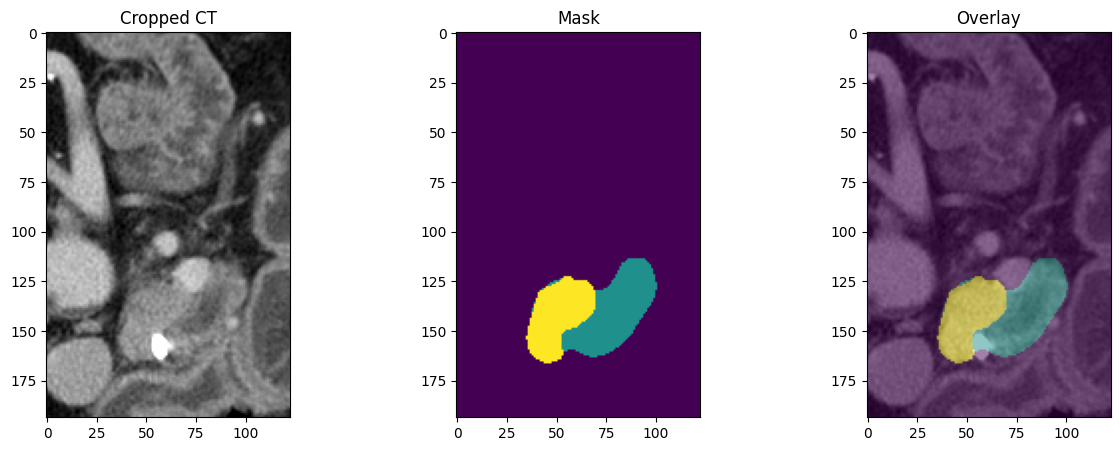

In [57]:
import matplotlib.pyplot as plt

slice_idx = cropped_volume.shape[2] // 2

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(
    cropped_volume[:,:,slice_idx],
    cmap="gray"
)
plt.title("Cropped CT")

plt.subplot(1,3,2)
plt.imshow(
    cropped_label[:,:,slice_idx]
)
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(
    cropped_volume[:,:,slice_idx],
    cmap="gray"
)

plt.imshow(
    cropped_label[:,:,slice_idx],
    alpha=0.5
)

plt.title("Overlay")

plt.show()

In [58]:
HU_MIN = -125
HU_MAX = 275

In [59]:
TARGET_SPACING = (1.0, 1.0, 2.0)

In [60]:
MARGIN_X = 20
MARGIN_Y = 20
MARGIN_Z = 10

In [61]:
print("Image Min:", cropped_volume.min())
print("Image Max:", cropped_volume.max())

print("Labels:",
      np.unique(cropped_label))

Image Min: 0.0
Image Max: 1.0
Labels: [0. 1. 2.]


In [63]:
!pip install -q nibabel
!pip install -q SimpleITK
!pip install -q scipy
!pip install -q tqdm

In [62]:
import os

processed_root = "/content/drive/MyDrive/Pancreatic Cancer Dataset/Processed"

os.makedirs(processed_root, exist_ok=True)

os.makedirs(
    os.path.join(processed_root,"images"),
    exist_ok=True
)

os.makedirs(
    os.path.join(processed_root,"labels"),
    exist_ok=True
)

In [64]:
HU_MIN = -125
HU_MAX = 275

TARGET_SPACING = (
    1.0,
    1.0,
    2.0
)

MARGIN_X = 20
MARGIN_Y = 20
MARGIN_Z = 10

In [65]:
import numpy as np
from scipy.ndimage import zoom

def preprocess_case(
        image_path,
        label_path):

    import nibabel as nib

    img = nib.load(image_path)
    lbl = nib.load(label_path)

    volume = img.get_fdata()
    mask = lbl.get_fdata()

    spacing = img.header.get_zooms()

    # ------------------
    # HU clipping
    # ------------------

    volume = np.clip(
        volume,
        HU_MIN,
        HU_MAX
    )

    # ------------------
    # Resampling
    # ------------------

    zoom_factors = [

        spacing[0]/TARGET_SPACING[0],

        spacing[1]/TARGET_SPACING[1],

        spacing[2]/TARGET_SPACING[2]

    ]

    volume = zoom(
        volume,
        zoom_factors,
        order=1
    )

    mask = zoom(
        mask,
        zoom_factors,
        order=0
    )

    # ------------------
    # ROI Extraction
    # ------------------

    coords = np.argwhere(mask > 0)

    xmin, ymin, zmin = coords.min(axis=0)
    xmax, ymax, zmax = coords.max(axis=0)

    xmin = max(0,xmin-MARGIN_X)
    ymin = max(0,ymin-MARGIN_Y)
    zmin = max(0,zmin-MARGIN_Z)

    xmax = min(
        volume.shape[0],
        xmax+MARGIN_X
    )

    ymax = min(
        volume.shape[1],
        ymax+MARGIN_Y
    )

    zmax = min(
        volume.shape[2],
        zmax+MARGIN_Z
    )

    volume = volume[
        xmin:xmax,
        ymin:ymax,
        zmin:zmax
    ]

    mask = mask[
        xmin:xmax,
        ymin:ymax,
        zmin:zmax
    ]

    # ------------------
    # Normalization
    # ------------------

    volume = (
        volume + 125
    ) / 400.0

    return volume, mask

In [66]:
from tqdm import tqdm
import nibabel as nib
import pandas as pd

audit = []

for case in tqdm(image_files[:10]):

    image_path = os.path.join(
        images_path,
        case
    )

    label_path = os.path.join(
        labels_path,
        case
    )

    volume, mask = preprocess_case(
        image_path,
        label_path
    )

    audit.append([

        case,

        volume.shape[0],
        volume.shape[1],
        volume.shape[2],

        volume.min(),
        volume.max(),

        len(np.unique(mask))

    ])

audit_df = pd.DataFrame(

    audit,

    columns=[

        "Case",

        "X",
        "Y",
        "Z",

        "Min",
        "Max",

        "Classes"

    ]

)

audit_df

100%|██████████| 10/10 [01:21<00:00,  8.15s/it]


,Case,X,Y,Z,Min,Max,Classes
0,pancreas_001.nii,139,93,56,-1.065814e-16,1.0,3
1,pancreas_004.nii,195,131,63,-1.065814e-16,1.0,3
2,pancreas_005.nii,159,128,70,-1.065814e-16,1.0,3
3,pancreas_006.nii,171,108,51,-7.105427e-17,1.0,3
4,pancreas_010.nii,196,133,74,-1.065814e-16,1.0,3
5,pancreas_012.nii,205,106,54,-1.065814e-16,1.0,3
6,pancreas_015.nii,152,126,57,-1.065814e-16,1.0,3
7,pancreas_016.nii,163,112,58,-1.065814e-16,1.0,3
8,pancreas_018.nii,134,111,60,-1.065814e-16,1.0,3
9,pancreas_019.nii,146,106,56,-1.065814e-16,1.0,3


In [68]:
coords = np.argwhere(mask > 0)

if len(coords) == 0:
    raise ValueError(
        f"No annotated region found in {image_path}"
    )

In [69]:
xmin, ymin, zmin = coords.min(axis=0)
xmax, ymax, zmax = coords.max(axis=0)

In [70]:
coords = np.argwhere(mask > 0)

if coords.shape[0] == 0:
    raise ValueError(
        f"Empty mask detected: {image_path}"
    )

In [72]:
nib.save(
    nib.Nifti1Image(
        volume.astype(np.float32),
        np.eye(4)
    ),
    image_save_path
)

NameError: name 'image_save_path' is not defined

In [73]:
print(processed_root)

/content/drive/MyDrive/Pancreatic Cancer Dataset/Processed


In [74]:
image_save_path = os.path.join(
    processed_root,
    "images",
    case
)

In [75]:
import os

print(os.listdir(processed_root))

['images', 'labels']


In [76]:
import os
import nibabel as nib
import numpy as np

case = image_files[0]

image_path = os.path.join(images_path, case)
label_path = os.path.join(labels_path, case)

volume, mask = preprocess_case(
    image_path,
    label_path
)

image_save_path = os.path.join(
    processed_root,
    "images",
    case
)

label_save_path = os.path.join(
    processed_root,
    "labels",
    case
)

nib.save(
    nib.Nifti1Image(
        volume.astype(np.float32),
        np.eye(4)
    ),
    image_save_path
)

nib.save(
    nib.Nifti1Image(
        mask.astype(np.uint8),
        np.eye(4)
    ),
    label_save_path
)

print("Saved Successfully")
print(image_save_path)
print(label_save_path)

Saved Successfully
/content/drive/MyDrive/Pancreatic Cancer Dataset/Processed/images/pancreas_001.nii
/content/drive/MyDrive/Pancreatic Cancer Dataset/Processed/labels/pancreas_001.nii


In [77]:
import os

print(
    len(
        os.listdir(
            os.path.join(processed_root,"images")
        )
    )
)

print(
    len(
        os.listdir(
            os.path.join(processed_root,"labels")
        )
    )
)

1
1


In [78]:
img = nib.load(image_save_path)
lbl = nib.load(label_save_path)

print("Image Shape:", img.shape)
print("Label Shape:", lbl.shape)

print(
    "Labels:",
    np.unique(
        lbl.get_fdata()
    )
)

Image Shape: (139, 93, 56)
Label Shape: (139, 93, 56)
Labels: [0. 1. 2.]


In [79]:
import pandas as pd
import os

log_file = os.path.join(
    processed_root,
    "processing_log.csv"
)

if not os.path.exists(log_file):

    pd.DataFrame(
        columns=[
            "Case",
            "Status",
            "Shape_X",
            "Shape_Y",
            "Shape_Z",
            "Pancreas_Voxels",
            "Cancer_Voxels"
        ]
    ).to_csv(
        log_file,
        index=False
    )

In [81]:
from tqdm import tqdm
import pandas as pd
import nibabel as nib
import numpy as np
import os

records = []

for case in tqdm(image_files):

    try:

        image_path = os.path.join(
            images_path,
            case
        )

        label_path = os.path.join(
            labels_path,
            case
        )

        volume, mask = preprocess_case(
            image_path,
            label_path
        )

        image_save_path = os.path.join(
            processed_root,
            "images",
            case
        )

        label_save_path = os.path.join(
            processed_root,
            "labels",
            case
        )

        nib.save(
            nib.Nifti1Image(
                volume.astype(np.float32),
                np.eye(4)
            ),
            image_save_path
        )

        nib.save(
            nib.Nifti1Image(
                mask.astype(np.uint8),
                np.eye(4)
            ),
            label_save_path
        )

        records.append([

            case,

            "Success",

            volume.shape[0],
            volume.shape[1],
            volume.shape[2],

            int(np.sum(mask==1)),
            int(np.sum(mask==2))

        ])

    except Exception as e:

        records.append([

            case,

            str(e),

            None,
            None,
            None,

            None,
            None

        ])

log_df = pd.DataFrame(

    records,

    columns=[

        "Case",
        "Status",

        "Shape_X",
        "Shape_Y",
        "Shape_Z",

        "Pancreas_Voxels",
        "Cancer_Voxels"
    ]
)

log_df.to_csv(
    os.path.join(
        processed_root,
        "preprocessing_audit.csv"
    ),
    index=False
)

100%|██████████| 281/281 [46:24<00:00,  9.91s/it]


In [82]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

SEED = 42

all_cases = sorted(image_files)

train_cases, temp_cases = train_test_split(
    all_cases,
    test_size=0.30,
    random_state=SEED
)

val_cases, test_cases = train_test_split(
    temp_cases,
    test_size=0.50,
    random_state=SEED
)

print("Train:", len(train_cases))
print("Validation:", len(val_cases))
print("Test:", len(test_cases))

Train: 196
Validation: 42
Test: 43


In [83]:
import json
import os

split_dir = os.path.join(
    processed_root,
    "splits"
)

os.makedirs(split_dir, exist_ok=True)

with open(
    os.path.join(split_dir,"train.json"),
    "w"
) as f:
    json.dump(train_cases,f)

with open(
    os.path.join(split_dir,"val.json"),
    "w"
) as f:
    json.dump(val_cases,f)

with open(
    os.path.join(split_dir,"test.json"),
    "w"
) as f:
    json.dump(test_cases,f)

In [84]:
print(
    len(
        set(train_cases)
        &
        set(val_cases)
    )
)

print(
    len(
        set(train_cases)
        &
        set(test_cases)
    )
)

print(
    len(
        set(val_cases)
        &
        set(test_cases)
    )
)

0
0
0
